--- STEP 1: Loading Data ---
--- STEP 2: Filtering and Quarterizing Financials ---
--- STEP 3: Feature Preprocessing & Point-In-Time Merge ---
--- STEP 4: Standardisation & Size Neutralisation ---
--- STEP 5: Walk-Forward CV Modeling ---
Fold 0: best_iter=41  mean_IC=0.0982  IC>0=83%
Fold 1: best_iter=6  mean_IC=0.0189  IC>0=67%
Fold 2: best_iter=243  mean_IC=0.0088  IC>0=67%
Fold 3: best_iter=49  mean_IC=-0.0222  IC>0=50%

=== OOS IC Summary (All Folds Combined) ===
Mean IC     : 0.0303
ICIR        : 0.3046
Annual ICIR : 1.0552
Avg monthly L/S return: 1.2241%
Annualised Sharpe     : 1.60


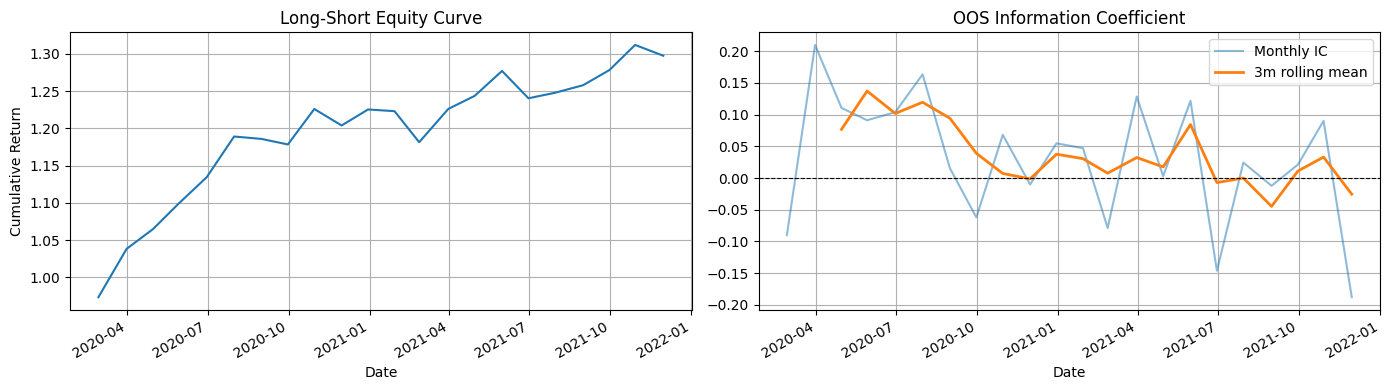

In [2]:
# %% [markdown]
# # XGBoost Stock Ranking Pipeline (Reproducible Version)
# Data Loading -> EDA & Quarterization -> Preprocessing -> Standardisation -> Walk-Forward Modeling

# %%
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from xgboost import XGBRanker
import joblib

warnings.filterwarnings('ignore')

# ==========================================================
# CONFIGURATION & PATHS
# ==========================================================
class Config:
    RAW_PRICES = r"C:\Users\naksh\Projects\xgboost_stock_ranking\data\raw\stock_prices.csv"
    RAW_FINANCIALS = r"C:\Users\naksh\Projects\xgboost_stock_ranking\data\raw\financials.csv"
    BEST_PARAMS = r"C:\Users\naksh\Projects\xgboost_stock_ranking\data\best_xgbranker_params.json"
    MODEL_DIR = r"C:\Users\naksh\Projects\xgboost_stock_ranking\models"
    
    TRAIN_END = "2020-01-01"
    N_QUINTILES = 5
    SIZE_PROXY = "avg_dollar_vol_1m"
    EPS = 1e-8

# ==========================================================
# PIPELINE FUNCTIONS
# ==========================================================

def clip_features(df, cols, q_low=0.01, q_high=0.99):
    """Safely clips specified columns to given quantiles."""
    for c in cols:
        if c in df.columns:
            lower = df[c].quantile(q_low)
            upper = df[c].quantile(q_high)
            df[c] = df[c].clip(lower, upper)
    return df

def pipeline_execution(config):
    # ---------------------------------------------------------
    # 1. LOAD DATA
    # ---------------------------------------------------------
    print("--- STEP 1: Loading Data ---")
    stock_prices = pd.read_csv(config.RAW_PRICES, low_memory=False)
    financials = pd.read_csv(config.RAW_FINANCIALS, low_memory=False)
    
    stock_prices["Date"] = pd.to_datetime(stock_prices["Date"])
    for col in ["Date", "DisclosedDate"]:
        if col in financials.columns:
            financials[col] = pd.to_datetime(financials[col])

    # ---------------------------------------------------------
    # 2. EDA & QUARTERIZATION
    # ---------------------------------------------------------
    print("--- STEP 2: Filtering and Quarterizing Financials ---")
    KEEP_DOCS = [
        "ForecastRevision", "1QFinancialStatements_Consolidated_JP",
        "2QFinancialStatements_Consolidated_JP", "3QFinancialStatements_Consolidated_JP",
        "FYFinancialStatements_Consolidated_JP",
    ]
    price_codes = set(stock_prices["SecuritiesCode"].unique())
    
    financials = financials[
        financials["TypeOfDocument"].isin(KEEP_DOCS) &
        financials["SecuritiesCode"].isin(price_codes)
    ].sort_values(["SecuritiesCode", "Date"]).copy()

    NUMERIC_COLS = [
        "NetSales", "OperatingProfit", "OrdinaryProfit", "Profit", "TotalAssets", "Equity",
        "BookValuePerShare", "EarningsPerShare", "ForecastNetSales", "ForecastOperatingProfit", 
        "ForecastOrdinaryProfit", "ForecastProfit", "ForecastEarningsPerShare", "AverageNumberOfShares",
        "NumberOfIssuedAndOutstandingSharesAtTheEndOfFiscalYearIncludingTreasuryStock",
        "NumberOfTreasuryStockAtTheEndOfFiscalYear", "EquityToAssetRatio"
    ]
    DIVIDEND_COLS = [
        "ResultDividendPerShare1stQuarter", "ResultDividendPerShare2ndQuarter", "ResultDividendPerShare3rdQuarter", 
        "ResultDividendPerShareFiscalYearEnd", "ResultDividendPerShareAnnual", "ForecastDividendPerShare1stQuarter", 
        "ForecastDividendPerShare2ndQuarter", "ForecastDividendPerShare3rdQuarter", "ForecastDividendPerShareFiscalYearEnd", 
        "ForecastDividendPerShareAnnual"
    ]
    financials[NUMERIC_COLS] = financials[NUMERIC_COLS].apply(pd.to_numeric, errors="coerce")
    financials[DIVIDEND_COLS] = financials[DIVIDEND_COLS].apply(pd.to_numeric, errors="coerce")

    STATEMENT_DOCS = [d for d in KEEP_DOCS if d != "ForecastRevision"]
    statements = financials[financials["TypeOfDocument"].isin(STATEMENT_DOCS)].copy()
    
    QUARTER_MAP = {doc: i+1 for i, doc in enumerate(STATEMENT_DOCS)}
    statements["quarter"] = statements["TypeOfDocument"].map(QUARTER_MAP)
    statements["fiscal_year"] = pd.to_datetime(statements["CurrentPeriodEndDate"]).dt.year
    statements = statements.sort_values(["SecuritiesCode", "fiscal_year", "quarter"])

    FLOW_COLS = ["NetSales", "OperatingProfit", "OrdinaryProfit", "Profit"]
    prev_quarter = statements.groupby(["SecuritiesCode", "fiscal_year"])["quarter"].shift(1)

    for col in FLOW_COLS:
        statements[f"q_{col}"] = np.nan
        q1_mask = statements["quarter"] == 1
        valid_mask = (statements["quarter"] > 1) & (prev_quarter == statements["quarter"] - 1)
        
        statements.loc[q1_mask, f"q_{col}"] = statements.loc[q1_mask, col]
        statements.loc[valid_mask, f"q_{col}"] = (
            statements.loc[valid_mask, col] - 
            statements.groupby(["SecuritiesCode", "fiscal_year"])[col].shift(1).loc[valid_mask]
        )

    # TTM Features
    ttm_base = ["q_NetSales", "q_OperatingProfit", "q_OrdinaryProfit", "q_Profit"]
    statements = statements.sort_values(["SecuritiesCode", "DisclosedDate"])
    for col in ttm_base:
        statements[f"{col}_ttm"] = statements.groupby("SecuritiesCode")[col].transform(
            lambda x: x.rolling(4, min_periods=4).sum()
        )

    # Bring back necessary features identically
    statements[["NumberOfIssuedAndOutstandingSharesAtTheEndOfFiscalYearIncludingTreasuryStock", "EarningsPerShare"]] = \
        financials[["NumberOfIssuedAndOutstandingSharesAtTheEndOfFiscalYearIncludingTreasuryStock", "EarningsPerShare"]]

    # ---------------------------------------------------------
    # 3. PREPROCESSING & MERGE
    # ---------------------------------------------------------
    print("--- STEP 3: Feature Preprocessing & Point-In-Time Merge ---")
    prices = stock_prices.sort_values(["SecuritiesCode", "Date"])
    
    statements["roe"] = statements["q_Profit"] / statements["Equity"]
    statements["roa"] = statements["q_Profit"] / statements["TotalAssets"]
    statements["profit_margin"] = statements["q_Profit"] / statements["q_NetSales"]
    statements["operating_margin"] = statements["q_OperatingProfit"] / statements["q_NetSales"]
    statements["asset_turnover"] = statements["q_NetSales"] / statements["TotalAssets"]
    statements["equity_ratio"] = statements["Equity"] / statements["TotalAssets"]
    statements["operating_roa"] = statements["q_OperatingProfit"] / statements["TotalAssets"]
    statements["ordinary_roa"] = statements["q_OrdinaryProfit"] / statements["TotalAssets"]
    statements["operating_roe"] = statements["q_OperatingProfit"] / statements["Equity"]
    statements["ordinary_roe"] = statements["q_OrdinaryProfit"] / statements["Equity"]
    statements["ordinary_margin"] = statements["q_OrdinaryProfit"] / statements["q_NetSales"]
    statements["profit_to_assets"] = statements["q_Profit"] / statements["TotalAssets"]
    statements["sales_to_equity"] = statements["q_NetSales"] / statements["Equity"]

    statements["ttm_roa"] = statements["q_Profit_ttm"] / statements["TotalAssets"]
    statements["ttm_roe"] = statements["q_Profit_ttm"] / statements["Equity"]
    statements["ttm_operating_roa"] = statements["q_OperatingProfit_ttm"] / statements["TotalAssets"]
    statements["ttm_operating_roe"] = statements["q_OperatingProfit_ttm"] / statements["Equity"]
    statements["ttm_profit_margin"] = statements["q_Profit_ttm"] / statements["q_NetSales_ttm"]
    statements["ttm_operating_margin"] = statements["q_OperatingProfit_ttm"] / statements["q_NetSales_ttm"]
    statements["ttm_ordinary_margin"] = statements["q_OrdinaryProfit_ttm"] / statements["q_NetSales_ttm"]
    statements["ttm_asset_turnover"] = statements["q_NetSales_ttm"] / statements["TotalAssets"]
    statements["ttm_sales_to_equity"] = statements["q_NetSales_ttm"] / statements["Equity"]
    statements["ttm_profit_to_assets"] = statements["q_Profit_ttm"] / statements["TotalAssets"]

    statements = statements.replace([np.inf, -np.inf], np.nan)
    
    # Financial Ratio Clipping
    ttm_cols = [c for c in statements.columns if c.startswith("ttm_")]
    statements = clip_features(statements, ttm_cols)

    profitability_cols = ["roe", "roa", "profit_margin", "operating_margin", "asset_turnover", "equity_ratio", "operating_roa", "ordinary_roa", "operating_roe", "ordinary_roe", "ordinary_margin", "profit_to_assets", "sales_to_equity"]
    statements = clip_features(statements, profitability_cols)

    growth_cols = ["q_NetSales", "q_Profit", "TotalAssets", "Equity"]
    for col in growth_cols:
        statements[f"{col}_yoy"] = statements.groupby("SecuritiesCode")[col].pct_change(4)
    growth_features = ["q_NetSales_yoy", "q_Profit_yoy", "TotalAssets_yoy", "Equity_yoy"]
    statements = clip_features(statements, growth_features)

    statements["forecast_operating_margin"] = statements["ForecastOperatingProfit"] / statements["ForecastNetSales"]
    statements["forecast_profit_margin"] = statements["ForecastProfit"] / statements["ForecastNetSales"]
    statements["forecast_roa"] = statements["ForecastProfit"] / statements["TotalAssets"]
    statements["forecast_roe"] = statements["ForecastProfit"] / statements["Equity"]
    statements["forecast_sales_growth"] = (statements["ForecastNetSales"] / statements["NetSales"]) - 1
    statements["forecast_profit_growth"] = (statements["ForecastProfit"] / statements["Profit"]) - 1
    statements["forecast_eps_growth"] = (statements["ForecastEarningsPerShare"] / statements["EarningsPerShare"]) - 1

    statements = statements.replace([np.inf, -np.inf], np.nan)
    forecast_cols = ["forecast_sales_growth", "forecast_profit_growth", "forecast_eps_growth", "forecast_operating_margin", "forecast_profit_margin", "forecast_roa", "forecast_roe"]
    statements = clip_features(statements, forecast_cols)

    accel_cols = ["roe", "roa", "profit_margin", "operating_margin", "ordinary_margin", "asset_turnover", "sales_to_equity", "ttm_roe", "ttm_roa", "ttm_profit_margin", "ttm_asset_turnover"]
    for col in accel_cols:
        statements[f"{col}_change_4q"] = statements.groupby("SecuritiesCode")[col].diff(4)
        
    change_4q_cols = [c for c in statements.columns if c.endswith("change_4q")]
    statements = clip_features(statements, change_4q_cols)

    # EXACT Feature List extraction from original notebook (prevents any logic skips)
    financial_features = [
        "Date", "SecuritiesCode", "NetSales", "Profit", "TotalAssets", "Equity", "q_NetSales", "q_OperatingProfit", "q_Profit",
        "roe", "roa", "profit_margin", "operating_margin", "asset_turnover", "equity_ratio", "operating_roa", "ordinary_roa", "operating_roe", "ordinary_roe", "ordinary_margin", "profit_to_assets", "sales_to_equity",
        "q_NetSales_yoy", "q_Profit_yoy", "TotalAssets_yoy", "Equity_yoy", "forecast_sales_growth", "forecast_profit_growth", "forecast_eps_growth", "forecast_operating_margin", "forecast_profit_margin", "forecast_roa", "forecast_roe",
        "q_NetSales_ttm", "q_OperatingProfit_ttm", "q_OrdinaryProfit_ttm", "q_Profit_ttm", "ttm_roa", "ttm_roe", "ttm_operating_roa", "ttm_operating_roe", "ttm_profit_margin", "ttm_operating_margin", "ttm_ordinary_margin", "ttm_asset_turnover", "ttm_sales_to_equity", "ttm_profit_to_assets",
        "roe_change_4q", "roa_change_4q", "profit_margin_change_4q", "operating_margin_change_4q", "ordinary_margin_change_4q", "asset_turnover_change_4q", "sales_to_equity_change_4q", "ttm_roe_change_4q", "ttm_roa_change_4q", "ttm_profit_margin_change_4q", "ttm_asset_turnover_change_4q"
    ]
    # Deduplicate but preserve order safely
    financial_features = list(dict.fromkeys(financial_features))

    statements_small = statements[financial_features].copy()
    statements_small[["NumberOfIssuedAndOutstandingSharesAtTheEndOfFiscalYearIncludingTreasuryStock", "EarningsPerShare"]] = statements[["NumberOfIssuedAndOutstandingSharesAtTheEndOfFiscalYearIncludingTreasuryStock", "EarningsPerShare"]]
    
    prices["SecuritiesCode"] = prices["SecuritiesCode"].astype("int64")
    statements_small["SecuritiesCode"] = statements_small["SecuritiesCode"].astype("int64")

    # Embargo Shift
    statements_small["Date"] = statements_small["Date"] + pd.Timedelta(days=1)
    
    prices = prices.sort_values(["Date", "SecuritiesCode"]).reset_index(drop=True)
    statements_small = statements_small.sort_values(["Date", "SecuritiesCode"]).reset_index(drop=True)

    merged = pd.merge_asof(prices, statements_small, on="Date", by="SecuritiesCode", direction="backward")

    # Resample Monthly
    merged["YearMonth"] = merged["Date"].dt.to_period("M")
    monthly = merged.sort_values(["SecuritiesCode", "Date"]).groupby(["SecuritiesCode", "YearMonth"], as_index=False).last()

    # Targets & Monthly Momentum Features
    monthly["target_1m"] = (monthly.groupby("SecuritiesCode")["Close"].shift(-1) / monthly["Close"]) - 1
    for m in [1, 3, 6, 12]:
        monthly[f"mom_{m}m"] = monthly.groupby("SecuritiesCode")["Close"].pct_change(m)
    for m in [3, 6, 12]:
        ma = monthly.groupby("SecuritiesCode")["Close"].transform(lambda x: x.rolling(m).mean())
        monthly[f"ma_{m}m_ratio"] = monthly["Close"] / ma

    # Daily Risk Features
    merged = merged.sort_values(["SecuritiesCode", "Date"])
    merged["daily_return"] = merged.groupby("SecuritiesCode")["Close"].pct_change()
    merged["market_return"] = merged.groupby("Date")["daily_return"].transform("mean")
    merged["idio_return"] = merged["daily_return"] - merged["market_return"]

    for days, name in zip([21, 63, 126], [1, 3, 6]):
        merged[f"idio_vol_{name}m"] = merged.groupby("SecuritiesCode")["idio_return"].transform(lambda x: x.rolling(days).std())
    for days, name in zip([63, 126], [3, 6]):
        merged[f"idio_skew_{name}m"] = merged.groupby("SecuritiesCode")["idio_return"].transform(lambda x: x.rolling(days).skew())
    for days, name in zip([21, 63, 126, 252], [1, 3, 6, 12]):
        merged[f"vol_{name}m"] = merged.groupby("SecuritiesCode")["daily_return"].transform(lambda x: x.rolling(days).std())
    for days, name in zip([63, 126, 252], [3, 6, 12]):
        merged[f"skew_{name}m"] = merged.groupby("SecuritiesCode")["daily_return"].transform(lambda x: x.rolling(days).skew())
    for days, name in zip([63, 126, 252], [3, 6, 12]):
        merged[f"max_return_{name}m"] = merged.groupby("SecuritiesCode")["daily_return"].transform(lambda x: x.rolling(days).max())

    merged["dollar_volume"] = merged["Close"] * merged["Volume"]
    for days, name in zip([21, 63], [1, 3]):
        merged[f"avg_dollar_vol_{name}m"] = merged.groupby("SecuritiesCode")["dollar_volume"].transform(lambda x: x.rolling(days).mean())
    merged["rel_volume"] = merged["Volume"] / merged.groupby("SecuritiesCode")["Volume"].transform(lambda x: x.rolling(63).mean())

    daily_feature_cols = [
        "vol_1m", "vol_3m", "vol_6m", "vol_12m", "skew_3m", "skew_6m", "skew_12m",
        "max_return_3m", "avg_dollar_vol_1m", "rel_volume"
    ]
    monthly = monthly.merge(merged[["SecuritiesCode", "Date"] + daily_feature_cols], on=["SecuritiesCode", "Date"], how="left")

    # Valuation Features
    def safe_div(num, den, eps=config.EPS):
        return num / den.where(den.abs() > eps)

    shares = monthly["NumberOfIssuedAndOutstandingSharesAtTheEndOfFiscalYearIncludingTreasuryStock"]
    monthly["market_cap"] = monthly["Close"] * shares
    monthly["log_market_cap"] = np.log1p(monthly["market_cap"])
    monthly["price_to_earnings"] = safe_div(monthly["Close"], monthly["EarningsPerShare"])
    monthly["earnings_yield"] = safe_div(monthly["EarningsPerShare"], monthly["Close"])

    monthly = monthly.replace([np.inf, -np.inf], np.nan)

    # Feature Cleanup
    drop_cols = ["YearMonth", "ExpectedDividend", "Target", "max_return_6m", "max_return_12m", "avg_dollar_vol_3m", "q_OrdinaryProfit"]
    monthly = monthly.drop(columns=[c for c in drop_cols if c in monthly.columns])

    exclude_cols = {"Date", "SecuritiesCode", "RowId", "target_1m", "Open", "High", "Low", "Close", "Volume", "ExpectedDividend", "Target", "market_cap"}
    feature_cols = [c for c in monthly.columns if c not in exclude_cols and monthly[c].dtype in ["float64", "float32", "int64", "int32"]]

    # Global Clipping Check
    monthly = clip_features(monthly, feature_cols)

    # ---------------------------------------------------------
    # 4. STANDARDISATION & SIZE-QUINTILE NEUTRALISATION
    # ---------------------------------------------------------
    print("--- STEP 4: Standardisation & Size Neutralisation ---")
    monthly = monthly.dropna(subset=["target_1m"])
    
    train_mask = monthly["Date"] < config.TRAIN_END
    target_lower = monthly.loc[train_mask, "target_1m"].quantile(0.01)
    target_upper = monthly.loc[train_mask, "target_1m"].quantile(0.99)
    monthly["target_1m"] = monthly["target_1m"].clip(target_lower, target_upper)

    monthly[feature_cols] = monthly.groupby("Date")[feature_cols].transform(lambda x: x.fillna(x.median()))
    monthly[feature_cols] = monthly[feature_cols].fillna(0)

    monthly["size_quintile"] = monthly.groupby("Date")[config.SIZE_PROXY].transform(
        lambda x: pd.qcut(x.rank(method="first"), q=config.N_QUINTILES, labels=False)
    )

    PRICE_EXACT = {"log_market_cap", "price_to_earnings", "earnings_yield", "dividend_yield", "forecast_dividend_yield", "treasury_share_ratio"}
    PRICE_PREFIXES = ["mom_", "ma_", "vol_", "skew_", "max_return_", "avg_dollar_vol_", "rel_volume", "AdjustmentFactor", "SupervisionFlag"]
    PRICE_FEATURES = [f for f in feature_cols if f in PRICE_EXACT or any(f.startswith(p) for p in PRICE_PREFIXES)]
    FUNDAMENTAL_FEATURES = [f for f in feature_cols if f not in PRICE_FEATURES]

    monthly[FUNDAMENTAL_FEATURES] = monthly.groupby(["Date", "size_quintile"])[FUNDAMENTAL_FEATURES].transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))
    monthly[PRICE_FEATURES] = monthly.groupby("Date")[PRICE_FEATURES].transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))
    monthly = monthly.drop(columns=["size_quintile"])

    # ---------------------------------------------------------
    # 5. MODEL TRAINING & WALK-FORWARD VALIDATION
    # ---------------------------------------------------------
    print("--- STEP 5: Walk-Forward CV Modeling ---")
    
    try:
        with open(config.BEST_PARAMS, "r") as f:
            best_params = json.load(f)
    except FileNotFoundError:
        print("Best params JSON not found! Using robust XGBoost fallback defaults.")
        best_params = {"learning_rate": 0.05, "max_depth": 5, "subsample": 0.8, "colsample_bytree": 0.8}

    monthly["rank_target"] = monthly.groupby("Date")["target_1m"].transform(
        lambda x: pd.qcut(x.rank(method="first"), q=32, labels=False)
    ).astype(int)

    MIN_TRAIN_MONTHS = 36
    TEST_FOLD_MONTHS = 6
    GAP_MONTHS = 1

    all_months = sorted(monthly["Date"].dt.to_period("M").unique())
    folds = []
    fold_start_idx = MIN_TRAIN_MONTHS

    while fold_start_idx + GAP_MONTHS < len(all_months):
        train_end_period = all_months[fold_start_idx - 1]
        test_start_period = all_months[fold_start_idx + GAP_MONTHS]
        test_end_idx = min(fold_start_idx + GAP_MONTHS + TEST_FOLD_MONTHS - 1, len(all_months) - 1)
        test_end_period = all_months[test_end_idx]

        folds.append({
            "train_end": train_end_period.to_timestamp(how="end"),
            "test_start": test_start_period.to_timestamp(how="start"),
            "test_end": test_end_period.to_timestamp(how="end"),
        })
        fold_start_idx += TEST_FOLD_MONTHS

    all_test_predictions = []
    trained_models = []
    
    for fold_idx, fold in enumerate(folds):
        train_df = monthly[monthly["Date"] <= fold["train_end"]].copy()
        test_df = monthly[(monthly["Date"] >= fold["test_start"]) & (monthly["Date"] <= fold["test_end"])].copy()

        if len(train_df) == 0 or len(test_df) == 0:
            continue

        val_cutoff = train_df["Date"].max() - pd.DateOffset(months=6)
        inner_train = train_df[train_df["Date"] <= val_cutoff]
        inner_valid = train_df[train_df["Date"] > val_cutoff]

        X_tr, y_tr = inner_train[feature_cols], inner_train["rank_target"]
        X_va, y_va = inner_valid[feature_cols], inner_valid["rank_target"]
        X_te = test_df[feature_cols]

        group_tr = inner_train.groupby("Date").size().to_list()
        group_va = inner_valid.groupby("Date").size().to_list()

        ranker = XGBRanker(
            objective="rank:pairwise",
            eval_metric="ndcg",
            n_estimators=1000,
            tree_method="hist",
            early_stopping_rounds=50,
            random_state=42,
            **best_params
        )

        ranker.fit(
            X_tr, y_tr, group=group_tr,
            eval_set=[(X_tr, y_tr), (X_va, y_va)], eval_group=[group_tr, group_va],
            verbose=False,
        )
        trained_models.append(ranker)

        test_df["score"] = ranker.predict(X_te)
        test_df["fold"] = fold_idx
        all_test_predictions.append(test_df)

        fold_ic = test_df.groupby("Date").apply(
            lambda x: spearmanr(x["score"], x["target_1m"]).correlation, include_groups=False
        )
        print(f"Fold {fold_idx}: best_iter={ranker.best_iteration}  mean_IC={fold_ic.mean():.4f}  IC>0={(fold_ic > 0).mean():.0%}")

    oos = pd.concat(all_test_predictions, ignore_index=True)
    
    # Validation Results
    monthly_ic = oos.groupby("Date").apply(lambda x: spearmanr(x["score"], x["target_1m"]).correlation, include_groups=False)
    icir = monthly_ic.mean() / (monthly_ic.std() + 1e-8)
    
    print("\n=== OOS IC Summary (All Folds Combined) ===")
    print(f"Mean IC     : {monthly_ic.mean():.4f}")
    print(f"ICIR        : {icir:.4f}")
    print(f"Annual ICIR : {icir * np.sqrt(12):.4f}")

    def long_short_return(df):
        df = df.sort_values("score")
        n = max(1, int(len(df) * 0.10))
        return df.iloc[-n:]["target_1m"].mean() - df.iloc[:n]["target_1m"].mean()

    portfolio = oos.groupby("Date").apply(long_short_return, include_groups=False)
    print(f"Avg monthly L/S return: {portfolio.mean():.4%}")
    print(f"Annualised Sharpe     : {portfolio.mean() / portfolio.std() * np.sqrt(12):.2f}")

    # Plot Equity Curve
    equity = (1 + portfolio).cumprod()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    equity.plot(ax=axes[0], title="Long-Short Equity Curve")
    axes[0].set_ylabel("Cumulative Return")
    axes[0].grid(True)
    
    monthly_ic.plot(ax=axes[1], alpha=0.5, label="Monthly IC")
    monthly_ic.rolling(3).mean().plot(ax=axes[1], label="3m rolling mean", linewidth=2)
    axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[1].set_title("OOS Information Coefficient")
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

# ==========================================================
# MAIN EXECUTION
# ==========================================================
if __name__ == "__main__":
    config = Config()
    pipeline_execution(config)